## WiFi Signal Modelling

Standalone notebook — loads the occupancy grid and evenly-spaced path CSV directly from disk.  
No dependency on notebook 6's kernel state.

In [ ]:
# ── Site paths  (*CHANGE HERE* for different sample data) ─────────────────────
site_path      = "../dataset/TuanMee_Site2/"
img_path       = site_path + "TuanMee_Site2_modified.tif"
site_path      = "./mosti_site/"
img_path       = site_path + "mosti_site.tif"

occupancy_path   = site_path + "occupancy_map.png"
even_path_csv    = site_path + "astar_evenly_spaced_local_path.csv"
crowns_path      = site_path + "crowns_exported.gpkg"

# ── Drone take-off position (lat, lon) ────────────────────────────────────────
home      = (3.272053, 101.454689)   # TuanMee_Site2
home    = (1.955062, 103.214438)   # mosti_site

# ── Ground Control Point / WiFi transmitter position (lat, lon) ───────────────
gcp       = (3.272100, 101.454615)
gcp     = (1.954982, 103.214520)

# Crown IDs to annotate on the map
visit_ids = [22, 36, 49] # TuanMee_Site2
visit_ids = [3, 5, 6]   # mosti_site

# ── WiFi / Channel Parameters ─────────────────────────────────────────────────
# Transmitter: D-Link DIR-X3060Z AX3000 WiFi 6 Router
# Receiver:    Intel AC8265 on Jetson Orin + Molex patch antenna
# Intel AX200 sensitivity floor: -80 dBm @ MCS0 HT20 — this is the -80 dBm target
FREQ_GHZ       = 2.4
PT_DBM         = 23.0    # DIR-X3060Z typical TX power (~200 mW)
GT_DBI         = 3.0     # DIR-X3060Z internal antenna gain
GR_DBI         = 2.9     # Molex patch antenna peak gain (boresight)
L_MISC_DB      = 4.5     # Cable loss + drone body shadowing + humidity derating
H_DRONE_M      = 15.0
H_GS_M         = 1.5

# ITU-R P.833-10 vegetation parameters — calibrated for humid oil palm at 2.4 GHz
# γ = 1.8 dB/m: mature water-dense oil palm (higher than 1.4 dB/m moderate broadleaf)
# A_m = 40 dB: saturation cap for tropical canopy at 2.4 GHz
# FREQ_REF_GHZ = FREQ_GHZ → (f/f_ref)^0.284 = 1.0, no scaling applied
GAMMA_REF_DB_M = 1.8     # dB/m specific attenuation — humid mature oil palm
FREQ_REF_GHZ   = 2.4     # reference = operating frequency → no frequency scaling
A_M_DB         = 40.0    # Saturation cap (dB) — tropical canopy, 2.4 GHz

# ── Contour display — 5 levels ────────────────────────────────────────────────
CONTOUR_LEVELS = [-80, -70, -60, -50, -40]
CONTOUR_COLORS = ["#111111", "#8B0000", "#CC2200", "#FF6600", "#FF8C00"]
CONTOUR_FILL_ALPHA = 0.1

# ── Path colours ──────────────────────────────────────────────────────────────
TRANSIT_COLOR  = "#00BFFF"   # bright sky-blue — transit segments
ORBIT_COLOR    = "#200274"   # dark red-purple — orbit segments
PATH_LINEWIDTH = 1.2

# ══════════════════════════════════════════════════════════════════════════════
# ── Advanced model feature flags  (set True/False to toggle each effect) ──────
# ══════════════════════════════════════════════════════════════════════════════

# 1. TRUNK SHADOW PENALTY
#    Adds a discrete dB penalty for each palm trunk the ray crosses, modelling
#    the sharp shadow zones that smooth ITU averaging misses.
ENABLE_TRUNK_SHADOW    = False
TRUNK_PENALTY_DB       = 12.0  # dB loss per trunk crossing (10–20 dB typical)

# 2. FRESNEL GROUND PENALTY
#    Adds extra loss when the first Fresnel zone grazes the ground, modelling
#    multi-path cancellation at low GCP / low-altitude links.
ENABLE_FRESNEL_GROUND  = False
FRESNEL_CLEARANCE_FRAC = 0.6   # fraction of r_F1 treated as minimum clearance
FRESNEL_MAX_PENALTY_DB = 10.0  # cap on the Fresnel ground penalty (dB)

# 3. PATCH ANTENNA PATTERN (orbit yaw effect)
#    Replaces fixed GR_DBI with a cos^n directional model during Orbit segments,
#    penalising the signal when the UAV yaws its antenna away from the GCP.
ENABLE_ANTENNA_PATTERN = False
PATCH_PEAK_DBI         = GR_DBI   # boresight gain (dBi) — same as GR_DBI above
PATCH_HPBW_DEG         = 65.0     # half-power beamwidth (degrees) for cos^n fit
PATCH_F2B_DB           = 15.0     # front-to-back ratio (dB) — sets null floor

# ══════════════════════════════════════════════════════════════════════════════

wifi_params = dict(
    freq_ghz=FREQ_GHZ, pt_dbm=PT_DBM, gt_dbi=GT_DBI, gr_dbi=GR_DBI,
    l_misc_db=L_MISC_DB, h_drone=H_DRONE_M, h_gs=H_GS_M,
    gamma_ref=GAMMA_REF_DB_M, a_m=A_M_DB, freq_ref_ghz=FREQ_REF_GHZ,
)

model_flags = dict(
    trunk_shadow    = ENABLE_TRUNK_SHADOW,
    trunk_penalty   = TRUNK_PENALTY_DB,
    fresnel_ground  = ENABLE_FRESNEL_GROUND,
    fresnel_frac    = FRESNEL_CLEARANCE_FRAC,
    fresnel_max     = FRESNEL_MAX_PENALTY_DB,
    antenna_pattern = ENABLE_ANTENNA_PATTERN,
    patch_peak      = PATCH_PEAK_DBI,
    patch_hpbw      = PATCH_HPBW_DEG,
    patch_f2b       = PATCH_F2B_DB,
)

print("Active model flags:")
for k, v in model_flags.items():
    print(f"  {k:<20} = {v}")

Active model flags:
  trunk_shadow         = True
  trunk_penalty        = 12.0
  fresnel_ground       = True
  fresnel_frac         = 0.6
  fresnel_max          = 10.0
  antenna_pattern      = True
  patch_peak           = 2.9
  patch_hpbw           = 65.0
  patch_f2b            = 15.0


In [2]:
import csv
import numpy as np
import rasterio
import geopandas as gpd
import pyproj
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from PIL import Image
from scipy.ndimage import distance_transform_edt, label

# ── 1. Load occupancy grid from PNG ───────────────────────────────────────────
img = Image.open(occupancy_path).convert("L")
arr = np.array(img)
occupancy_grid = np.where(arr > 128, 0, 1).astype(np.uint8)  # 1=tree, 0=free
print(f"Occupancy grid: {occupancy_grid.shape}  "
      f"(free={np.sum(occupancy_grid==0)}, occupied={np.sum(occupancy_grid==1)})")

# ── 2. Get UTM bounds and CRS from GeoTIFF ────────────────────────────────────
with rasterio.open(img_path) as src:
    utm_bounds = src.bounds
    utm_crs    = src.crs
bx0, by0, bx1, by1 = utm_bounds.left, utm_bounds.bottom, utm_bounds.right, utm_bounds.top
print(f"UTM bounds: ({bx0:.1f}, {by0:.1f}, {bx1:.1f}, {by1:.1f})  CRS: {utm_crs}")

transformer = pyproj.Transformer.from_crs("EPSG:4326", utm_crs, always_xy=True)

# ── 3. Convert home (take-off) → UTM — defines local coordinate origin ────────
home_utm_x, home_utm_y = transformer.transform(home[1], home[0])
print(f"Home UTM (local origin): ({home_utm_x:.2f}, {home_utm_y:.2f})")

# ── 4. Convert GCP → UTM — signal radiates from here ─────────────────────────
gcp_utm_x, gcp_utm_y = transformer.transform(gcp[1], gcp[0])
gcp_loc_x = gcp_utm_x - home_utm_x
gcp_loc_y = gcp_utm_y - home_utm_y
print(f"GCP UTM:   ({gcp_utm_x:.2f}, {gcp_utm_y:.2f})")
print(f"GCP local: ({gcp_loc_x:.2f}, {gcp_loc_y:.2f}) m from Home")

# ── 5. Load evenly-spaced path CSV (local coords, home = 0, 0) ────────────────
xs_loc, ys_loc, states = [], [], []
with open(even_path_csv, newline="") as f:
    for row in csv.DictReader(f):
        xs_loc.append(float(row["x_local"]))
        ys_loc.append(float(row["y_local"]))
        states.append(row["state"])
xs_loc = np.array(xs_loc)
ys_loc = np.array(ys_loc)
print(f"Path loaded: {len(xs_loc)} waypoints  "
      f"(orbit={states.count('Orbit')}, transit={states.count('Normal')})")

# ── 6. Crown waypoints in local coords ────────────────────────────────────────
crowns = gpd.read_file(crowns_path)
if crowns.crs != "EPSG:4326":
    crowns = crowns.to_crs("EPSG:4326")

world_coords_local = {}   # {crown_id: (local_x, local_y)}
for idx, row in crowns.iterrows():
    crown_id = idx + 1
    if crown_id not in visit_ids:
        continue
    cx_utm, cy_utm = transformer.transform(
        row.geometry.centroid.x, row.geometry.centroid.y)
    world_coords_local[crown_id] = (cx_utm - home_utm_x, cy_utm - home_utm_y)
print(f"Waypoints loaded: {list(world_coords_local.keys())}")

# ── 7. Build trunk-core grid via distance transform ───────────────────────────
# The occupancy grid uses inflated circles for path planning clearance.

H_occ, W_occ = occupancy_grid.shape
px_per_m = W_occ / (bx1 - bx0)          # pixels per metre

TRUNK_RADIUS_M = 0.30                    # physical trunk radius (m) — oil palm + epiphytes

# Measure inflated blob radius from the occupancy grid itself
_, n_blobs = label(occupancy_grid)
if n_blobs > 0:
    inflation_radius_m = np.sqrt(occupancy_grid.sum() / (np.pi * n_blobs))
else:
    inflation_radius_m = 2.15            # fallback

# Erosion distance = how deep we cut into each blob (in pixels)
erosion_m  = max(0.0, inflation_radius_m - TRUNK_RADIUS_M)
erosion_px = erosion_m * px_per_m

# EDT: distance (px) from each occupied pixel to the nearest free pixel
dist_px = distance_transform_edt(occupancy_grid)

# Keep only pixels deeper than the erosion threshold → trunk cores
trunk_grid = (dist_px > erosion_px).astype(np.uint8)
n_trunks_found = label(trunk_grid)[1]

print(f"\nTrunk-core grid:")
print(f"  px/m                    : {px_per_m:.2f}")
print(f"  Inflated blob radius    : {inflation_radius_m:.2f} m")
print(f"  Trunk radius            : {TRUNK_RADIUS_M} m")
print(f"  Erosion distance        : {erosion_m:.2f} m  ({erosion_px:.1f} px)")
print(f"  Trunk-core blobs found  : {n_trunks_found}  "
      f"(occupied px: {trunk_grid.sum()})")

Occupancy grid: (780, 1378)  (free=866444, occupied=208396)
UTM bounds: (969057.5, 216652.5, 969195.2, 216730.4)  CRS: EPSG:32647
Home UTM (local origin): (969115.35, 216683.34)
GCP UTM:   (969124.51, 216674.50)
GCP local: (9.17, -8.84) m from Home
Path loaded: 22 waypoints  (orbit=18, transit=4)
Waypoints loaded: [3, 5, 6]

Trunk-core grid:
  px/m                    : 10.00
  Inflated blob radius    : 32.19 m
  Trunk radius            : 0.3 m
  Erosion distance        : 31.89 m  (319.0 px)
  Trunk-core blobs found  : 0  (occupied px: 0)


In [3]:
# ── Channel model ─────────────────────────────────────────────────────────────

def free_space_pl(d_m, freq_ghz):
    """FSPL = 20log(d) + 20log(f) + 20log(4π/c)"""
    d_m = np.maximum(d_m, 0.1)
    return (20*np.log10(d_m)
            + 20*np.log10(freq_ghz)
            + 20*np.log10(4*np.pi*1e9/3e8))

def itu_p833_veg_loss(freq_ghz, depth_m, gamma_ref, a_m, freq_ref_ghz=0.433):
    """
    ITU-R P.833-10 saturating vegetation loss (dB).
      γ(f) = γ_ref · (f/f_ref)^0.284
      A_veg = A_m · (1 − exp(−depth·γ / A_m))
    """
    gamma = gamma_ref * (freq_ghz / freq_ref_ghz) ** 0.284
    depth = np.maximum(depth_m, 0)
    return a_m * (1 - np.exp(-depth * gamma / a_m))

# ── Feature 1: Trunk shadow penalty ───────────────────────────────────────────

def count_trunk_crossings(occ_samples):
    """
    Count distinct trunk crossings (0→1 transitions) along each ray.
    occ_samples : ndarray shape (N_points, n_samples) — occupancy values {0,1}
                  Should use the trunk-core grid, NOT the inflated occupancy grid.
    Returns     : ndarray shape (N_points,) of int counts
    """
    transitions = np.diff(occ_samples.astype(np.int8), axis=1)
    return (transitions == 1).sum(axis=1)

# ── Feature 2: Fresnel ground penalty ─────────────────────────────────────────

def fresnel_ground_penalty(r_2d, h_drone, h_gs, freq_ghz,
                            clearance_frac=0.6, max_penalty_db=10.0):
    """
    Extra loss (dB) when the first Fresnel zone grazes the ground.

    At mid-path the first Fresnel zone radius is r_F1 = sqrt(λ·d/4).
    The minimum antenna height sets the available vertical clearance.
    When clearance < clearance_frac · r_F1 the penalty rises linearly,
    capped at max_penalty_db.
    """
    wavelength = 3e8 / (freq_ghz * 1e9)
    r_2d  = np.asarray(r_2d, dtype=float)
    d_3d  = np.sqrt(r_2d**2 + (h_drone - h_gs)**2)
    r_F1  = np.sqrt(wavelength * d_3d / 4.0)
    h_min = min(h_gs, h_drone)
    deficit = r_F1 * clearance_frac - h_min
    penalty = np.clip(deficit * 2.0, 0.0, max_penalty_db)
    return penalty

# ── Feature 3: Directional patch antenna gain ──────────────────────────────────

def patch_gain_db(theta_deg, peak_dbi=2.9, hpbw_deg=65.0, f2b_db=15.0):
    """
    cos^n approximation for a patch antenna's receive gain (dBi).
    n derived so that cos(HPBW/2)^n = 0.5  →  n = ln(0.5)/ln(cos(HPBW/2))
    """
    hpbw_rad  = np.radians(hpbw_deg / 2.0)
    n         = np.log(0.5) / np.log(np.cos(hpbw_rad))
    theta_rad = np.radians(np.clip(np.abs(np.asarray(theta_deg, dtype=float)), 0, 180))
    gain_lin  = np.cos(theta_rad / 2.0) ** n
    floor_lin = 10 ** (-f2b_db / 10.0)
    return peak_dbi + 10 * np.log10(np.maximum(gain_lin, floor_lin))

def orbit_off_boresight_angle(xs, ys, gcp_lx, gcp_ly):
    """
    Estimate the off-boresight angle (degrees) at each waypoint for orbit segments.
    UAV heading = path tangent (finite difference); antenna boresight = forward.
    """
    xs, ys = np.asarray(xs, dtype=float), np.asarray(ys, dtype=float)
    n = len(xs)
    dx = np.empty(n); dy = np.empty(n)
    dx[1:-1] = xs[2:] - xs[:-2];  dy[1:-1] = ys[2:] - ys[:-2]
    dx[0]    = xs[1]  - xs[0];    dy[0]    = ys[1]  - ys[0]
    dx[-1]   = xs[-1] - xs[-2];   dy[-1]   = ys[-1] - ys[-2]
    heading_rad = np.arctan2(dy, dx)
    gcp_dir_rad = np.arctan2(gcp_ly - ys, gcp_lx - xs)
    diff = np.degrees(np.abs(heading_rad - gcp_dir_rad))
    return np.where(diff > 180, 360 - diff, diff)

# ── Unified ray-cast ───────────────────────────────────────────────────────────

def ray_cast(lx, ly, occ_grid, bounds, gcp_utm_x, gcp_utm_y,
             home_utm_x, home_utm_y, n_samples=80, trunk_grid=None):
    """
    Ray-cast from GCP to every point in (lx, ly).

    Parameters
    ----------
    occ_grid   : inflated occupancy grid — used for vegetation depth (ITU loss)
    trunk_grid : trunk-core grid (eroded) — used for crossing counts.
                 If None, falls back to occ_grid (overcounts, not recommended).

    Returns
    -------
    d_v   : vegetation depth (m)  — from inflated occ_grid
    n_trk : trunk crossing count  — from trunk_grid (tight trunk cores only)
    """
    bx0, by0, bx1, by1 = bounds
    H, W = occ_grid.shape

    flat_x_utm = np.asarray(lx).ravel().astype(float) + home_utm_x
    flat_y_utm = np.asarray(ly).ravel().astype(float) + home_utm_y
    N       = len(flat_x_utm)
    ray_len = np.sqrt((flat_x_utm - gcp_utm_x)**2 + (flat_y_utm - gcp_utm_y)**2)

    _trunk = occ_grid if trunk_grid is None else trunk_grid

    t     = np.linspace(0.0, 1.0, n_samples)
    d_v   = np.zeros(N, dtype=float)
    n_trk = np.zeros(N, dtype=int)
    chunk = 4000

    for start in range(0, N, chunk):
        sl  = slice(start, min(start + chunk, N))
        rx  = gcp_utm_x + t[None, :] * (flat_x_utm[sl, None] - gcp_utm_x)
        ry  = gcp_utm_y + t[None, :] * (flat_y_utm[sl, None] - gcp_utm_y)
        col = np.clip(((rx - bx0) / (bx1 - bx0) * (W - 1)).astype(int), 0, W-1)
        row = np.clip(((by1 - ry) / (by1 - by0) * (H - 1)).astype(int), 0, H-1)
        # Vegetation depth from inflated grid
        d_v[sl]   = occ_grid[row, col].mean(axis=1) * ray_len[sl]
        # Trunk crossings from tight trunk-core grid
        n_trk[sl] = count_trunk_crossings(_trunk[row, col])

    shape = np.asarray(lx).shape
    return d_v.reshape(shape), n_trk.reshape(shape)

def ray_cast_veg_depth(lx, ly, occ_grid, bounds, gcp_utm_x, gcp_utm_y,
                       home_utm_x, home_utm_y, n_samples=80):
    """Legacy wrapper — returns vegetation depth only."""
    d_v, _ = ray_cast(lx, ly, occ_grid, bounds, gcp_utm_x, gcp_utm_y,
                      home_utm_x, home_utm_y, n_samples)
    return d_v

# ── Received power — full link budget with optional advanced effects ───────────

def received_power(lx, ly, p, gcp_lx, gcp_ly,
                   d_v=None, n_trunks=None, theta_deg=None, flags=None):
    """
    Received power (dBm) at local coords (lx, ly).

    Link budget:
      Pr = Pt + Gt + Gr(θ) − FSPL − A_veg − L_misc
           − trunk_penalty × N_trunks     [if flags['trunk_shadow']]
           − fresnel_ground_penalty       [if flags['fresnel_ground']]
    """
    if flags is None:
        flags = {}

    lx = np.asarray(lx, dtype=float)
    ly = np.asarray(ly, dtype=float)

    r    = np.sqrt((lx - gcp_lx)**2 + (ly - gcp_ly)**2)
    r    = np.maximum(r, 0.5)
    d    = np.sqrt(r**2 + (p["h_drone"] - p["h_gs"])**2)
    fspl = free_space_pl(d, p["freq_ghz"])

    depth = r if d_v is None else np.maximum(np.asarray(d_v, dtype=float), 0.0)
    lveg  = itu_p833_veg_loss(p["freq_ghz"], depth,
                              p["gamma_ref"], p["a_m"], p["freq_ref_ghz"])

    if flags.get("antenna_pattern") and theta_deg is not None:
        gr = patch_gain_db(theta_deg,
                           peak_dbi = flags.get("patch_peak", p["gr_dbi"]),
                           hpbw_deg = flags.get("patch_hpbw", 65.0),
                           f2b_db   = flags.get("patch_f2b",  15.0))
    else:
        gr = p["gr_dbi"]

    pr = p["pt_dbm"] + p["gt_dbi"] + gr - fspl - lveg - p["l_misc_db"]

    if flags.get("trunk_shadow") and n_trunks is not None:
        pr = pr - np.asarray(n_trunks, dtype=float) * flags.get("trunk_penalty", 12.0)

    if flags.get("fresnel_ground"):
        fp = fresnel_ground_penalty(
            r, p["h_drone"], p["h_gs"], p["freq_ghz"],
            clearance_frac = flags.get("fresnel_frac", 0.6),
            max_penalty_db = flags.get("fresnel_max", 10.0))
        pr = pr - fp

    return pr

print("Channel model functions defined.")

Channel model functions defined.


In [4]:
# ── Signal grid (1 m resolution, local coordinates) ───────────────────────────

lx0, ly0 = bx0 - home_utm_x, by0 - home_utm_y
lx1, ly1 = bx1 - home_utm_x, by1 - home_utm_y

res = 1.0
xi  = np.arange(lx0, lx1 + res, res)
yi  = np.arange(ly0, ly1 + res, res)
LX, LY = np.meshgrid(xi, yi)

print(f"Grid: {LX.shape}  East [{lx0:.0f}, {lx1:.0f}] m  North [{ly0:.0f}, {ly1:.0f}] m")
print("Ray-casting signal grid...", end=" ", flush=True)

DV_grid, NT_grid = ray_cast(LX, LY, occupancy_grid,
                             (bx0, by0, bx1, by1),
                             gcp_utm_x, gcp_utm_y, home_utm_x, home_utm_y,
                             trunk_grid=trunk_grid)

PR = received_power(LX, LY, wifi_params, gcp_loc_x, gcp_loc_y,
                    d_v=DV_grid, n_trunks=NT_grid, theta_deg=None,
                    flags=model_flags)
print("done.")
print(f"  Trunk crossings — max: {NT_grid.max()}  mean: {NT_grid.mean():.2f}")

Grid: (79, 139)  East [-58, 80] m  North [-31, 47] m
Ray-casting signal grid... done.
  Trunk crossings — max: 0  mean: 0.00


In [5]:
# ── Path signal ───────────────────────────────────────────────────────────────

print("Ray-casting path points...", end=" ", flush=True)
dv_path, nt_path = ray_cast(xs_loc, ys_loc, occupancy_grid,
                             (bx0, by0, bx1, by1),
                             gcp_utm_x, gcp_utm_y, home_utm_x, home_utm_y,
                             trunk_grid=trunk_grid)
print("done.")

states_arr = np.array(states)
orbit_mask_path   = states_arr == "Orbit"
transit_mask_path = states_arr == "Normal"

# Per-waypoint off-boresight angle:
#   - Orbit points: computed from path tangent vs GCP direction
#   - Transit points: theta=0 (antenna aimed forward, roughly toward GCP)
theta_path = np.zeros(len(xs_loc), dtype=float)
if model_flags.get("antenna_pattern") and orbit_mask_path.any():
    orbit_idx = np.where(orbit_mask_path)[0]
    run_start = orbit_idx[0]; prev = orbit_idx[0]; runs = []
    for idx in orbit_idx[1:]:
        if idx == prev + 1:
            prev = idx
        else:
            runs.append((run_start, prev)); run_start = idx; prev = idx
    runs.append((run_start, prev))
    for s, e in runs:
        sl = slice(s, e + 1)
        theta_path[sl] = orbit_off_boresight_angle(
            xs_loc[sl], ys_loc[sl], gcp_loc_x, gcp_loc_y)

pr_path = received_power(xs_loc, ys_loc, wifi_params, gcp_loc_x, gcp_loc_y,
                         d_v=dv_path, n_trunks=nt_path,
                         theta_deg=theta_path, flags=model_flags)

def split_segments_by_state(xs, ys, states_arr, target_state):
    runs = []; in_run = False
    for i, s in enumerate(states_arr):
        if s == target_state:
            if not in_run: run_x, run_y = [xs[i]], [ys[i]]; in_run = True
            else: run_x.append(xs[i]); run_y.append(ys[i])
        else:
            if in_run: runs.append((np.array(run_x), np.array(run_y))); in_run = False
    if in_run: runs.append((np.array(run_x), np.array(run_y)))
    return runs

orbit_runs   = split_segments_by_state(xs_loc, ys_loc, states_arr, "Orbit")
transit_runs = split_segments_by_state(xs_loc, ys_loc, states_arr, "Normal")

print(f"Path Pr — min: {pr_path.min():.1f} dBm  "
      f"max: {pr_path.max():.1f} dBm  mean: {pr_path.mean():.1f} dBm")
if model_flags.get("antenna_pattern"):
    orbit_theta = theta_path[orbit_mask_path]
    if len(orbit_theta):
        print(f"  Orbit θ (off-boresight) — mean: {orbit_theta.mean():.1f}°  "
              f"max: {orbit_theta.max():.1f}°")

Ray-casting path points... done.
Path Pr — min: -71.8 dBm  max: -40.6 dBm  mean: -53.4 dBm
  Orbit θ (off-boresight) — mean: 89.0°  max: 179.8°


/tmp/ipykernel_667046/3166851580.py:86: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dv_wp = float(ray_cast_veg_depth(


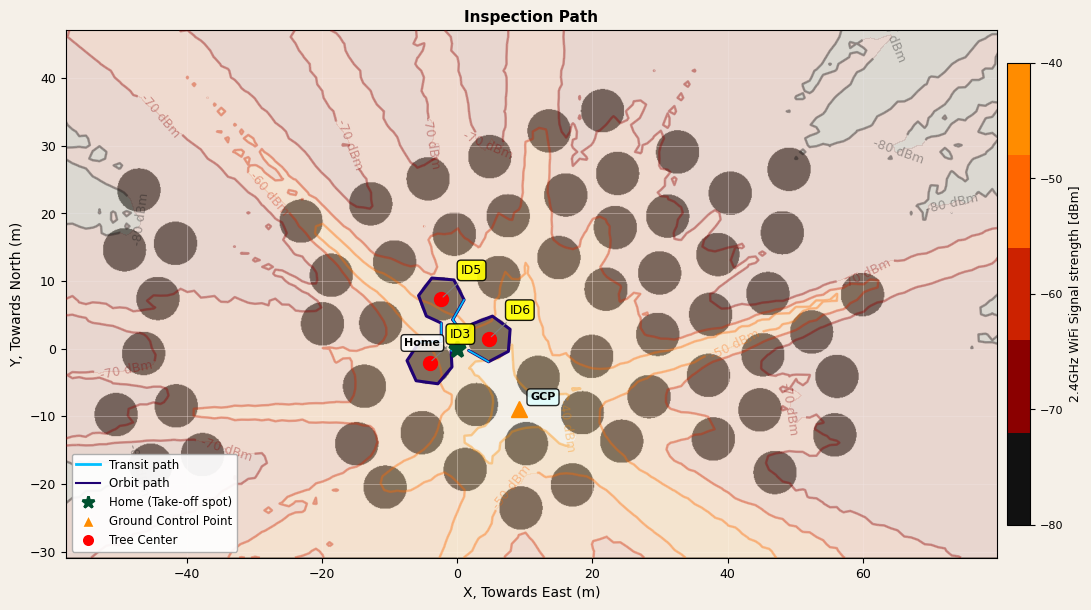

Saved → ./mosti_site/wifi_signal_strength_map_local.png
View: X=[-57.9, 79.9] m   Y=[-30.9, 47.1] m


In [6]:
# ── Figure ────────────────────────────────────────────────────────────────────
# ── Plot view limits (local coords, metres from Home)  ────────────────────────
# Set to None to use the full extent of the occupancy grid on that axis.
PLOT_X_MIN = None   # None → lx0
PLOT_X_MAX = None   # None → lx1
PLOT_Y_MIN = None   # None → ly0
PLOT_Y_MAX = None   # None → ly1

_xmin = lx0 if PLOT_X_MIN is None else PLOT_X_MIN
_xmax = lx1 if PLOT_X_MAX is None else PLOT_X_MAX
_ymin = ly0 if PLOT_Y_MIN is None else PLOT_Y_MIN
_ymax = ly1 if PLOT_Y_MAX is None else PLOT_Y_MAX

# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(1, 1, figsize=(11, 8), facecolor="#f5f0e8")
ax.set_facecolor("#e8e0d0")

# Occupancy map background
ax.imshow(occupancy_grid, extent=[lx0, lx1, ly0, ly1],
          cmap="Grays", origin="upper", alpha=0.5, zorder=1)

# ── Contour fill ──────────────────────────────────────────────────────────────
cf = ax.contourf(LX, LY, PR, levels=CONTOUR_LEVELS,
                 colors=CONTOUR_COLORS, alpha=CONTOUR_FILL_ALPHA,
                 extend="min", zorder=2)

# Labelled contour lines (with dBm units)
cs = ax.contour(LX, LY, PR, levels=CONTOUR_LEVELS,
                colors=CONTOUR_COLORS, linewidths=1.8, alpha=0.35, zorder=3)
ax.clabel(cs, inline=True,
          fmt={lvl: f"{lvl} dBm" for lvl in CONTOUR_LEVELS},
          fontsize=9, inline_spacing=4, zorder=4)

# ── Path segments — orbit drawn first, transit on top ────────────────────────
all_x        = np.array(xs_loc)
all_y        = np.array(ys_loc)
states_arr_np = np.array(states)
transit_mask = states_arr_np == "Normal"
orbit_mask   = states_arr_np == "Orbit"

def get_contiguous_segments(mask, xs, ys):
    segs, i, n = [], 0, len(mask)
    while i < n:
        if mask[i]:
            j = i
            while j < n and mask[j]:
                j += 1
            start = max(0, i - 1)
            end   = min(n - 1, j)
            segs.append((xs[start:end+1], ys[start:end+1]))
            i = j
        else:
            i += 1
    return segs

orbit_segs   = get_contiguous_segments(orbit_mask,   all_x, all_y)
transit_segs = get_contiguous_segments(transit_mask, all_x, all_y)

for rx, ry in orbit_segs:
    ax.plot(rx, ry, color=ORBIT_COLOR, linewidth=PATH_LINEWIDTH + 1,
            solid_capstyle="round", zorder=11)
for rx, ry in transit_segs:
    ax.plot(rx, ry, color=TRANSIT_COLOR, linewidth=PATH_LINEWIDTH,
            solid_capstyle="round", zorder=12)

# ── Markers ───────────────────────────────────────────────────────────────────
# Home — green star
ax.plot(0, 0, marker="*", markersize=12, markeredgewidth=2.5, zorder=15, color="#00502f")
ax.annotate("Home", (0, 0), xytext=(-38, 2),
            textcoords="offset points", fontsize=8, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85),
            zorder=17)

# GCP — orange upward triangle (pyramid)
ax.plot(gcp_loc_x, gcp_loc_y, "^", color="darkorange",
        markersize=11, zorder=15)
ax.annotate("GCP", (gcp_loc_x, gcp_loc_y), xytext=(8, 6),
            textcoords="offset points", fontsize=8, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcyan", alpha=0.85),
            zorder=17)

# ── Crown waypoint labels ─────────────────────────────────────────────────────
crown_data = []
for vid, (wx_loc, wy_loc) in world_coords_local.items():
    dv_wp = float(ray_cast_veg_depth(
        np.array([wx_loc]), np.array([wy_loc]), occupancy_grid,
        (bx0, by0, bx1, by1), gcp_utm_x, gcp_utm_y, home_utm_x, home_utm_y))
    pr_wp = float(received_power(wx_loc, wy_loc, wifi_params,
                                  gcp_loc_x, gcp_loc_y, d_v=dv_wp))
    crown_data.append((vid, wx_loc, wy_loc, pr_wp))

label_offsets = {
    36: ( 22, -28),
    22: ( 22,  -18),
    49: ( 22,  -18),
}

for vid, wx_loc, wy_loc, pr_wp in crown_data:
    ax.plot(wx_loc, wy_loc, "ro", markersize=10, zorder=15)
    ox, oy = label_offsets.get(vid, (22, 18))
    ax.annotate(f"ID{vid}", (wx_loc, wy_loc), xytext=(ox, oy),
                textcoords="offset points", fontsize=9,
                ha="center",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.90),
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.8),
                zorder=16)

# ── Colourbar ─────────────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(
    cmap=mcolors.ListedColormap(CONTOUR_COLORS),
    norm=Normalize(vmin=CONTOUR_LEVELS[0], vmax=CONTOUR_LEVELS[-1]))
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.024, pad=0.01, shrink=0.6)
cb.set_label("2.4GHz WiFi Signal strength [dBm]", fontsize=9)
cb.set_ticks(CONTOUR_LEVELS)
cb.ax.tick_params(labelsize=8)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elems = [
    Line2D([0],[0], color=TRANSIT_COLOR, linewidth=2.0, label="Transit path"),
    Line2D([0],[0], color=ORBIT_COLOR,   linewidth=1.5, label="Orbit path"),
    Line2D([0],[0], marker="*", color="#00502f", markersize=9,
           markeredgewidth=2, linestyle="None", label="Home (Take-off spot)"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="darkorange",
           markersize=9, linestyle="None", label="Ground Control Point"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="red",
           markersize=9, linestyle="None", label="Tree Center"),
]
ax.legend(handles=legend_elems, loc="lower left", fontsize=8.5,
          framealpha=0.93, edgecolor="#aaa", facecolor="white")

ax.set_xlim(_xmin, _xmax)
ax.set_ylim(_ymin, _ymax)
ax.set_xlabel("X, Towards East (m)", fontsize=10)
ax.set_ylabel("Y, Towards North (m)", fontsize=10)
ax.set_title("Inspection Path", fontsize=11, fontweight="bold")
ax.set_aspect("equal")
ax.grid(True, color="white", linewidth=0.5, alpha=0.5, zorder=1)
ax.tick_params(labelsize=9)

plt.tight_layout()
out_png = site_path + "wifi_signal_strength_map_local.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {out_png}")
print(f"View: X=[{_xmin:.1f}, {_xmax:.1f}] m   Y=[{_ymin:.1f}, {_ymax:.1f}] m")

In [7]:
# ── Console summary ───────────────────────────────────────────────────────────

# Active model flags
print("Model configuration:")
flag_labels = {
    "trunk_shadow":    f"Trunk shadow penalty  ({TRUNK_PENALTY_DB} dB/trunk)",
    "fresnel_ground":  f"Fresnel ground penalty (max {FRESNEL_MAX_PENALTY_DB} dB)",
    "antenna_pattern": f"Patch antenna pattern  (HPBW={PATCH_HPBW_DEG}°, F/B={PATCH_F2B_DB} dB)",
}
for key, label in flag_labels.items():
    status = "ON " if model_flags.get(key) else "OFF"
    print(f"  [{status}] {label}")

print(f"\n{'Point':<16} {'East (m)':>10} {'North (m)':>10} {'Pr (dBm)':>10}")
print("-" * 50)

def _eval_point(lx, ly, dv=None, nt=None, theta=None):
    dv_val = np.array([0.0]) if dv is None else np.array([float(dv)])
    nt_val = np.array([0])   if nt is None else np.array([int(nt)])
    th_val = np.array([0.0]) if theta is None else np.array([float(theta)])
    return float(received_power(
        np.array([lx]), np.array([ly]), wifi_params,
        gcp_loc_x, gcp_loc_y,
        d_v=dv_val, n_trunks=nt_val, theta_deg=th_val,
        flags=model_flags))

pr_gcp  = _eval_point(gcp_loc_x, gcp_loc_y, dv=0.0, nt=0)
pr_home = _eval_point(0.0, 0.0)
print(f"{'GCP':<16} {gcp_loc_x:>10.1f} {gcp_loc_y:>10.1f} {pr_gcp:>10.1f}")
print(f"{'Home':<16} {0.0:>10.1f} {0.0:>10.1f} {pr_home:>10.1f}")

for vid, (wx_loc, wy_loc) in world_coords_local.items():
    dv_wp, nt_wp = ray_cast(
        np.array([wx_loc]), np.array([wy_loc]), occupancy_grid,
        (bx0, by0, bx1, by1), gcp_utm_x, gcp_utm_y, home_utm_x, home_utm_y)
    pr_wp = _eval_point(wx_loc, wy_loc, dv=float(dv_wp), nt=int(nt_wp))
    print(f"{'Crown '+str(vid):<16} {wx_loc:>10.1f} {wy_loc:>10.1f} {pr_wp:>10.1f}")

print(f"\nPath Pr — min : {pr_path.min():.1f} dBm")
print(f"Path Pr — max : {pr_path.max():.1f} dBm")
print(f"Path Pr — mean: {pr_path.mean():.1f} dBm")

orbit_pr   = pr_path[orbit_mask_path]
transit_pr = pr_path[transit_mask_path]
if len(orbit_pr):
    print(f"\nOrbit   — mean: {orbit_pr.mean():.1f} dBm  min: {orbit_pr.min():.1f} dBm")
if len(transit_pr):
    print(f"Transit — mean: {transit_pr.mean():.1f} dBm  min: {transit_pr.min():.1f} dBm")

Model configuration:
  [ON ] Trunk shadow penalty  (12.0 dB/trunk)
  [ON ] Fresnel ground penalty (max 10.0 dB)
  [ON ] Patch antenna pattern  (HPBW=65.0°, F/B=15.0 dB)

Point              East (m)  North (m)   Pr (dBm)
--------------------------------------------------
GCP                     9.2       -8.8      -38.3
Home                    0.0        0.0      -41.0
Crown 3                -4.1       -2.0      -77.3
Crown 5                -2.4        7.4      -79.0
Crown 6                 4.7        1.5      -58.2

Path Pr — min : -71.8 dBm
Path Pr — max : -40.6 dBm
Path Pr — mean: -53.4 dBm

Orbit   — mean: -55.8 dBm  min: -71.8 dBm
Transit — mean: -42.9 dBm  min: -48.3 dBm


/tmp/ipykernel_667046/4100725419.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(received_power(
/tmp/ipykernel_667046/4100725419.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pr_wp = _eval_point(wx_loc, wy_loc, dv=float(dv_wp), nt=int(nt_wp))
